# Pytorch Inference model Testing

In this notebook, we will test the inference of a Pytorch model. We will load an already trained torchvision model. and we will perform a prediction on a sample Leo Messi image

## 1. Installing the necessary libraries

We use Pytorch and Torchvision to load the model and perform the inference. We will also use Matplotlib to visualize the results. And we will install Torchinfo to display the model's structure and wiew the size of it. You may need to restart the kernel after installing the libraries.


In [ ]:
%pip install torchvision torchinfo torch --quiet

In [1]:
import matplotlib.pyplot as plt
from torchvision.io import read_image
from torchvision.utils import save_image, make_grid
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
from torchvision.transforms import v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import torchvision
from pathlib import Path
from torchinfo import summary
import torch

## 2. Using the correct device

Here we check if we have a GPU available. If we do, we will use it. Otherwise, we will use the CPU.

In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}: {torch.cuda.get_device_name(0) if device.type == 'cuda' else 'CPU'}")


Using device: cpu: CPU


## 3. Loading a full model

We will load a trainable model, note that we set weights_only as False, this should only be done when you are in a trusted environment. We manually set the device in the parameters so that we can use the GPU if available and we don't get an error if the model was trained in a GPU device and loaded in the CPU. We also set the model to evaluation mode with eval()

In [ ]:
modelpath = Path("../models")

trainable_model = torch.load(modelpath / "trainable_model.pt",weights_only=False,map_location=device)
trainable_model.eval()

summary(trainable_model)

Layer (type:depth-idx)                                  Param #
MaskRCNN                                                --
├─GeneralizedRCNNTransform: 1-1                         --
├─BackboneWithFPN: 1-2                                  --
│    └─IntermediateLayerGetter: 2-1                     --
│    │    └─Conv2d: 3-1                                 (9,408)
│    │    └─FrozenBatchNorm2d: 3-2                      --
│    │    └─ReLU: 3-3                                   --
│    │    └─MaxPool2d: 3-4                              --
│    │    └─Sequential: 3-5                             (212,992)
│    │    └─Sequential: 3-6                             1,212,416
│    │    └─Sequential: 3-7                             7,077,888
│    │    └─Sequential: 3-8                             14,942,208
│    └─FeaturePyramidNetwork: 2-2                       --
│    │    └─ModuleList: 3-9                             984,064
│    │    └─ModuleList: 3-10                            2,360,320
│    

## 4. Loading an inference-only model, and reinstating its weights

Here, we load our pretrained model without the optimizer state, this requires that you have the exact same model architecture as the one used to train the model, to solve this in this case, we recreate the architecture and the use load_state_dict to use the weights of our saved model. Note that, because we don't want to fine-tune it further, we do not need to set an optimizer. And again, we set the model to inference mode with eval() and set the device manually to the one we are using.

In [15]:
# we re-do the model to show the summary AND to be able to load the inference-only model

base_model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
num_classes = 2

# get number of input features for the classifier
in_features = base_model.roi_heads.box_predictor.cls_score.in_features
# replace the pre-trained head with a new one
base_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# now get the number of input features for the mask classifier
in_features_mask = base_model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
# and replace the mask predictor with a new one
base_model.roi_heads.mask_predictor = MaskRCNNPredictor(
    in_features_mask,
    hidden_layer,
    num_classes
)

inference_model = base_model
# load the trained weights
inference_model.load_state_dict(
    torch.load(modelpath / "inference_model.pt", map_location=device)
)
inference_model.eval()
inference_model.to(device)
summary(inference_model)

Layer (type:depth-idx)                                  Param #
MaskRCNN                                                --
├─GeneralizedRCNNTransform: 1-1                         --
├─BackboneWithFPN: 1-2                                  --
│    └─IntermediateLayerGetter: 2-1                     --
│    │    └─Conv2d: 3-1                                 (9,408)
│    │    └─FrozenBatchNorm2d: 3-2                      --
│    │    └─ReLU: 3-3                                   --
│    │    └─MaxPool2d: 3-4                              --
│    │    └─Sequential: 3-5                             (212,992)
│    │    └─Sequential: 3-6                             1,212,416
│    │    └─Sequential: 3-7                             7,077,888
│    │    └─Sequential: 3-8                             14,942,208
│    └─FeaturePyramidNetwork: 2-2                       --
│    │    └─ModuleList: 3-9                             984,064
│    │    └─ModuleList: 3-10                            2,360,320
│    

## 5. Testing the model

In this section, we download an image, display it, and then we predict with the model on it. Next, we display the predicted bounding boxes over the image and see if the result makes sense

In [ ]:
messipic_url = "https://raw.githubusercontent.com/prathamSharma25/Lionel-Messi-Career-Analysis-EDA-ML/37c640dac09ae7a8759433d3980889171c5789d7/Images/lionel_messi.jpg"

# run this on linux
# !wget $messipic_url -O lionel_messi.jpg

# run this on windows
!Powershell.exe -Command "wget $messipic_url -OutFile lionel_messi.jpg"

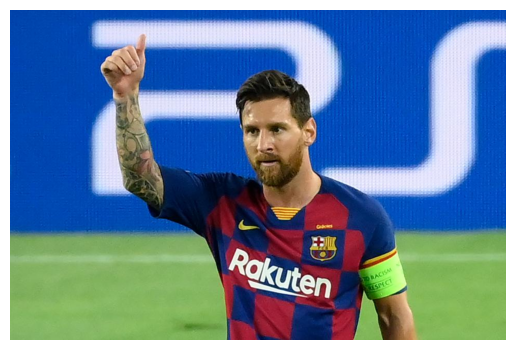

In [25]:
img = read_image("lionel_messi.jpg")

plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.show()

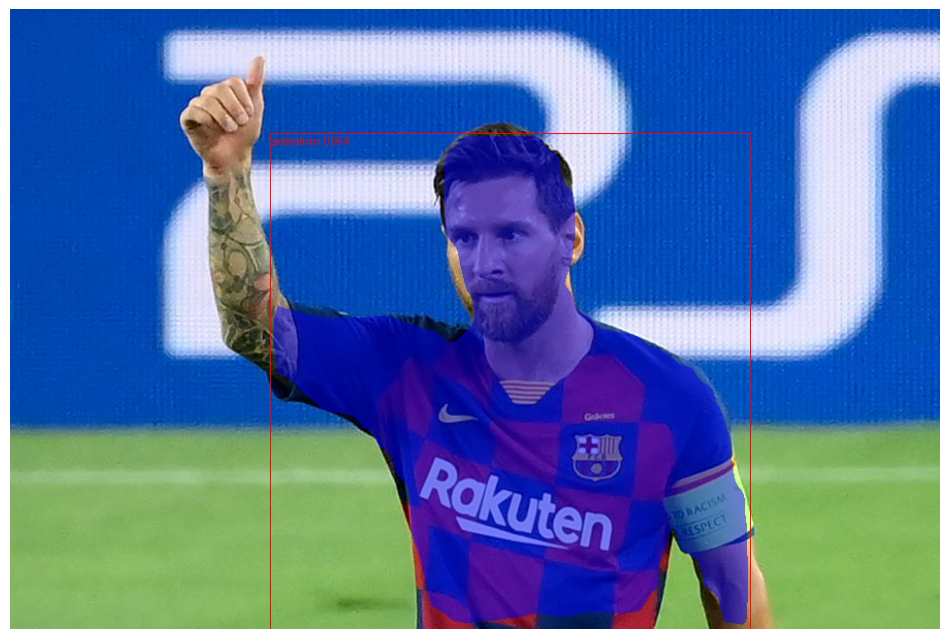

In [26]:
inference_transform = v2.Compose(
    [v2.ToDtype(torch.float, scale=True), v2.ToPureTensor()]
)

with torch.no_grad():
    x = inference_transform(img)
    # convert RGBA -> RGB and move to device
    x = x[:3, ...].to(device)
    predictions = inference_model(
        [
            x,
        ]
    )
    pred = predictions[0]
    # Filter predictions with score > 0.5
    score_mask = pred["scores"] > 0.5
    pred = {
        "labels": pred["labels"][score_mask],
        "scores": pred["scores"][score_mask],
        "boxes": pred["boxes"][score_mask],
        "masks": pred["masks"][score_mask],
    }


image = (255.0 * (img - img.min()) / (img.max() - img.min())).to(torch.uint8)
image = image[:3, ...]


pred_labels = [
    f"pedestrian: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])
]
pred_boxes = pred["boxes"].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

masks = (pred["masks"] > 0.7).squeeze(1)
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")


plt.figure(figsize=(12, 12))
plt.axis("off")
plt.imshow(output_image.permute(1, 2, 0))
plt.show()